# FFT for Image Processing

We use the ``Images`` of Julia, which is a collection of packages for image processing in Julia.

In [1]:
using Images

## 1. Images as Matrices of RGB codes

Let us look at a familiar picture, available in the current folder where the Jupyter notebook was launced.  Instead of the simple file name, the absolute path name may have to be provided.

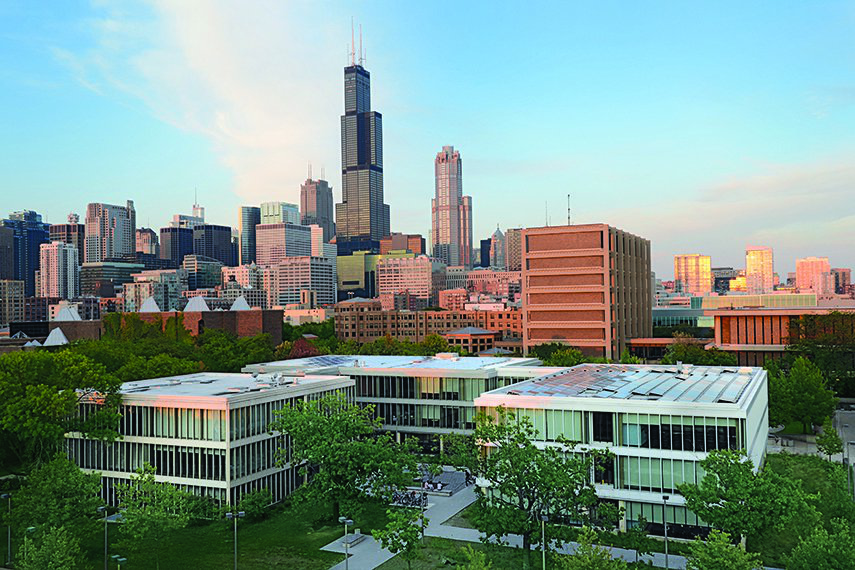

In [2]:
A = load("buildingsky.png")

The images has two dimensions, as can be seen from the output of ``size(A)`` below.

In [3]:
size(A)

(570, 855)

Let us look at the middle of the picture, selecting 20 pixels up and down the middle.

In [4]:
m1 = Int(size(A,1)/2)
m2 = Int(round(size(A,2)/2))

428

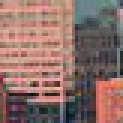

In [5]:
Amiddle = A[m1-20:m1+20,m2-20:m2+20]

In [6]:
#save("buildingskymiddle.png", Amiddle)

Let us look at one element of the matrix.

In [7]:
a = A[1,1]

In [8]:
typeof(a)

RGB{N0f8}

In [9]:
dump(a)

RGB{N0f8}
  r: N0f8
    i: UInt8 0x81
  g: N0f8
    i: UInt8 0xd3
  b: N0f8
    i: UInt8 0xfb


The ``a`` stores the red, green, and blue intensities, as three unsigned one byte integers.

In [10]:
a.r

0.506N0f8

In [11]:
Float32(a.r)

0.5058824f0

We convert to grayscale by averaging the red, green, and blue intensities.

In [12]:
agray = RGB{Float32}((Float32(a.r) + Float32(a.g) + Float32(a.b))/3)

In [13]:
Agray = zeros(size(A,1), size(A,2))
Agray = Matrix{RGB{Float32}}(Agray)
for i=1:size(A,1)
    for j=1:size(A,2)
        a = A[i,j]
        b = RGB{Float32}((Float32(a.r) + Float32(a.g) + Float32(a.b))/3)
        Agray[i,j] = b
    end
end

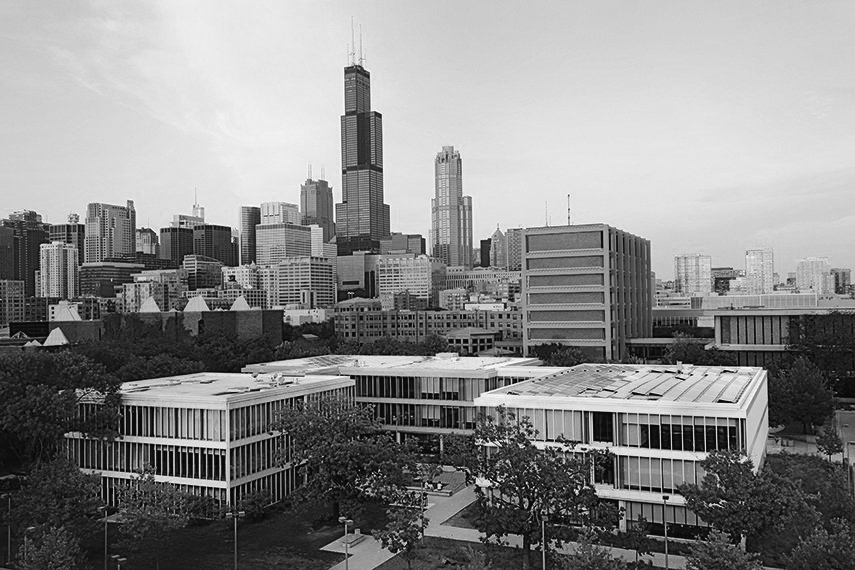

In [14]:
Agray

In [15]:
#save("buildingskygrayscale.png", Agray)

In [16]:
dump(Agray[1,1])

RGB{Float32}
  r: Float32 0.772549f0
  g: Float32 0.772549f0
  b: Float32 0.772549f0


As a result of the grayscale conversion, the red, green, and blue intensities are the same, so we may reduce the matrix to a matrix of floating point numbers.

In [17]:
C = zeros(size(Agray,1), size(Agray,2))
for i=1:size(Agray,1)
    for j=1:size(Agray,2)
        C[i,j] = Agray[i,j].r
    end
end

In [18]:
typeof(C)

Matrix{Float64} (alias for Array{Float64, 2})

Now we can compute with ``C``.

## 2. Blurring an Image

In [19]:
B = randn(size(C,1), size(C,1))
Y = B*C
D = zeros(size(Y,1), size(Y,2))
D = Matrix{RGB{Float32}}(D)
for i=1:size(Y,1)
    for j=1:size(Y,2)
        a = Y[i,j]
        if a < 0
            a = 0.0
        end
        if a > 1
            a = 1.0
        end
        D[i,j]= RGB{Float32}(a,a,a)
    end
end

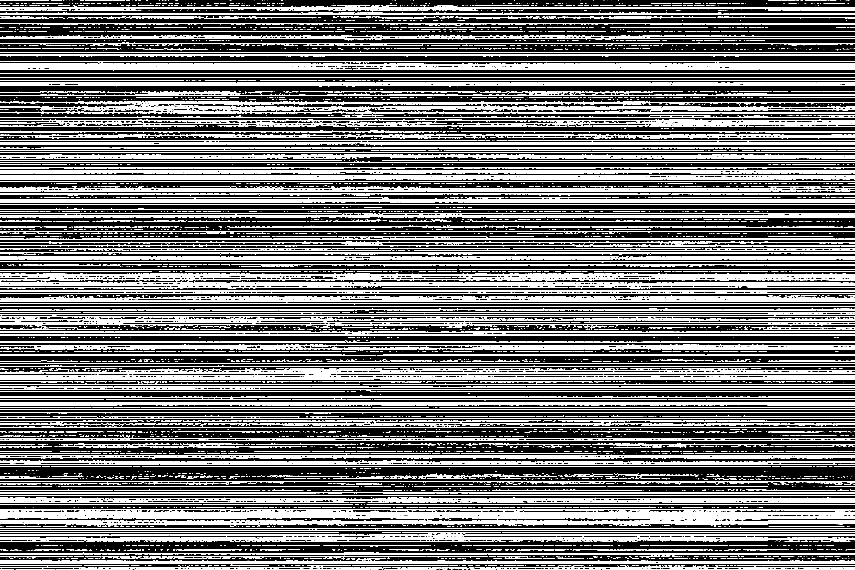

In [20]:
D

There is not much to see in the blurred image...

In [21]:
#save("buildingskyblurred.png", D)

Let us deblur with the inverse of B.

In [22]:
X = (B^-1)*Y
E = zeros(size(X,1), size(X,2))
E = Matrix{RGB{Float32}}(E)
for i=1:size(Y,1)
    for j=1:size(Y,2)
        a = X[i,j]
        E[i,j]= RGB{Float32}(a,a,a)
    end
end

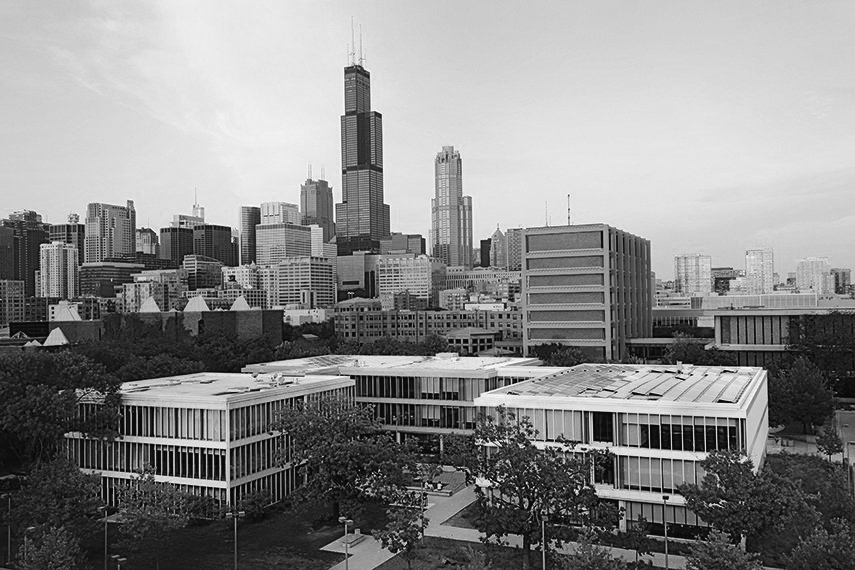

In [23]:
E

In [24]:
#save("buildingskyinvdeblurred.png", E)

Now the matrix-matrix multiplication is too expensive an operation.
Instead we replace the blurring operation with the componentwise product.

In [25]:
using FFTW

We have to extend the blur matrix so it has as many columns as the original image.
We do this by adding ones on the diagonal and zeros off the diagonal.

In [26]:
BB = zeros(size(C,2), size(C,2))
BB[1:size(B,1),1:size(B,2)] = B
for i in size(B,1)+1:size(BB,1)
    BB[i,i] = 1.0
end

In [27]:
fftB = fft(BB)
fftC = fft(C)
fftY = zeros(size(C,1), size(C,2))
fftY = Matrix{Complex{Float64}}(fftY)
for i=1:size(C,1)
    for j=1:size(C,2)
        fftY[i,j] = fftB[i,j]*fftC[i,j]
    end
end

In [28]:
fftX = zeros(size(C,1), size(C,2))
fftX = Matrix{Complex{Float64}}(fftY)
for i=1:size(C,1)
    for j=1:size(C,2)
        fftX[i,j] = fftY[i,j]/fftB[i,j]
    end
end

In [29]:
X = ifft(fftX)
deblurred = zeros(size(X,1), size(X,2))
deblurred = Matrix{RGB{Float32}}(deblurred)
for i=1:size(X,1)
    for j=1:size(X,2)
        x = Float32(real(X[i,j]))
        deblurred[i,j] = RGB{Float32}(x,x,x)
    end
end

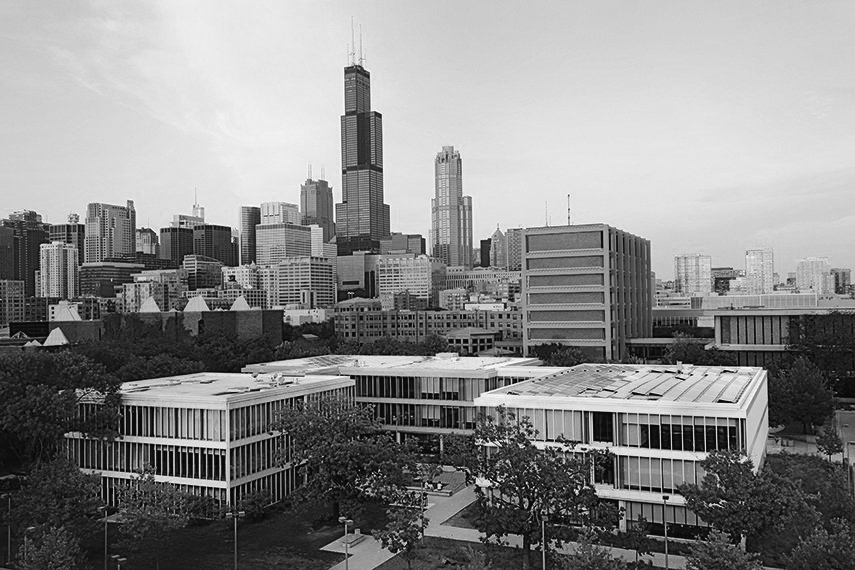

In [30]:
deblurred

In [31]:
#save("buildingskyfftdeblurred.png", deblurred)